# Immunogenetic analysis of grandiosity in schizophrenia: a gated, selection-aware re-analysis of the IL-10 -819/-592 locus

Reproducible analysis notebook. It loads the interleukin-genotype and OPCRIT phenotype data, derives the grandiosity phenotype and the IL-10 -819/-592 dose, and runs the pre-registered gated analysis with honest handling of selection, effect shape, and multiplicity.

This version corrects four issues found on review of the earlier notebook:
1. The genotype effect is estimated and reported in its true shape (recessive in two-copy carriers), not as a single additive per-copy odds ratio, and it is estimated with Firth penalized logistic regression because the informative cell is small (Firth 1993; Heinze and Schemper 2002).
2. Selection is made explicit. IL-10 is the smallest of eight gene p-values, so its significance is reported after a selection-adjusted permutation that re-runs the whole eight-gene screen on each shuffle, and it is tested with selection separated from evaluation in a repeated discovery and held-out split.
3. The IL-10 gene-set result is shown to be a single -819/-592 locus (two tag SNPs in near-complete linkage disequilibrium), not a gene-wide effect. The label is kept descriptive rather than asserting a functional low-producer direction that the data do not confirm.
4. The pre-registered primary tests (aggregate genotype and latent loadings) are reported first and are null, so the single-locus result is presented as a gated, exploratory, single-cohort finding, not as a validated one. All predictive steps confine every data-learned transformation to training folds.

**Inputs**: `interleukiny_genotypy.xlsx` (genotypes), `opcrit_baza.xlsx` (OPCRIT ratings).
**Outputs**: `Table1_demographics.csv`, `Figure1_narrative.png`, `Figure2_contribution.png`.

**References (DOIs verified online):**
- Sequence kernel association test (SKAT): Wu MC, Lee S, Cai T, Li Y, Boehnke M, Lin X. 2011, Am J Hum Genet 89(1):82-93, doi:10.1016/j.ajhg.2011.05.029
- Chi-square approximation for the SKAT null (Liu method): Liu H, Tang Y, Zhang HH. 2009, Comput Stat Data Anal 53(4):853-856, doi:10.1016/j.csda.2008.11.025
- Firth penalized logistic regression: Firth D. 1993, Biometrika 80(1):27-38, doi:10.1093/biomet/80.1.27
- Firth penalization for small or separated samples: Heinze G, Schemper M. 2002, Stat Med 21(16):2409-2419, doi:10.1002/sim.1047
- OPCRIT phenotype instrument: McGuffin P, Farmer A, Harvey I. 1991, Arch Gen Psychiatry 48(8):764-770, doi:10.1001/archpsyc.1991.01810320088015
- IL-10 promoter polymorphisms and schizophrenia susceptibility: Gao L, Li Z, Chang S, Wang J. 2014, PLoS One 9(3):e90407, doi:10.1371/journal.pone.0090407


## 0. Configuration and imports

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from collections import Counter
from scipy import stats, optimize
from scipy.integrate import quad
from scipy.stats import gaussian_kde, ncx2
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize
from matplotlib.cm import ScalarMappable

# reproducibility
MASTER_SEED = 20260704
np.random.seed(MASTER_SEED)

# data paths: edit to point to your copies of the two files
GENO_PATH   = "interleukiny_genotypy.xlsx"
OPCRIT_PATH = "opcrit_baza.xlsx"
GENO_KEY, OPCRIT_KEY, VNTR_COL = "Nowy numer kodu", "nowy_nr_kodu", "Il1RA (86bp) -Genotypy"
DISEASE_COL = "Choroba"   # genotype file: 0 = control, 4 = schizophrenia

# permutation and resampling budgets (raise for a final run)
N_PERM_SEL, N_SPLIT_HONEST, N_PERM_AMP, N_SPLIT = 3000, 500, 200, 100

# publication palette (grey for data and nulls, coral for the located signal)
CORAL, GREY, DGREY = "#EA5B5D", "#8D8D8D", "#484d54"
sns.set_style("white")
plt.rcParams.update({"axes.grid": False, "figure.dpi": 120, "axes.edgecolor": "#333",
                     "font.size": 15.5, "axes.titlesize": 13.5, "axes.labelsize": 15, "xtick.labelsize": 13.5, "ytick.labelsize": 13.5, "legend.fontsize": 12, "axes.titleweight": "bold",
                     "legend.frameon": False, "savefig.bbox": "tight"})
CORALS = LinearSegmentedColormap.from_list("c", ["#e2e5e9","#f0a58f",CORAL,"#a5140f"])
PURPCM = LinearSegmentedColormap.from_list("p", ["#f4eff8","#c9b8e6","#8b6fc4","#3f1a70"])
TGP    = LinearSegmentedColormap.from_list("tgp",["#1f7a63","#5DBFA9","#bfe3d8","#ece9e3","#ece9e3","#c9b8e6","#8b6fc4","#3f1a70"])
GREYCM = LinearSegmentedColormap.from_list("g", ["#c4c9cf","#9198a0","#484d54"])

# ---- figure export: journal specification ----
# Frontiers wants 300 dpi at final size, RGB, and no text smaller than 8 pt.
# Every figure is therefore drawn at its final width and saved as an LZW TIFF.
FIG_RC = {"font.size": 8, "axes.titlesize": 9.5, "axes.labelsize": 8.5,
          "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
          "axes.titlepad": 13.0, "figure.dpi": 300, "savefig.dpi": 600,
          "font.family": "DejaVu Sans"}

def save_tiff(fig, path, dpi=300):
    """Save as an RGB, LZW-compressed TIFF at the given dpi."""
    from PIL import Image
    fig.savefig(path, dpi=dpi, bbox_inches="tight",
                pil_kwargs={"compression": "tiff_lzw"})
    im = Image.open(path)
    if im.mode != "RGB":
        bg = Image.new("RGB", im.size, (255, 255, 255))
        bg.paste(im, mask=im.split()[-1] if im.mode == "RGBA" else None)
        im = bg
    im.save(path, compression="tiff_lzw", dpi=(dpi, dpi))


## 1. Embedded methods

Everything the analysis needs is defined here so the notebook is self-contained: the additive genotype encoding, the gene-set variance-component test (SKAT) with an exact Davies p-value and the fast Liu chi-square approximation used inside permutation loops, the rank inverse-normal transform, Firth penalized logistic regression with profile-likelihood intervals, Hardy-Weinberg testing, and Benjamini-Hochberg FDR.

In [2]:
# ---- rank inverse-normal transform (Blom) ----
def rint(x):
    x = np.asarray(x, float); ranks = stats.rankdata(x)
    return stats.norm.ppf((ranks - 0.5) / len(x))

# ---- SKAT: exact Davies p-value (used for observed statistics) ----
def davies_pvalue(q, lam):
    lam = np.asarray(lam, float); lam = lam[np.abs(lam) > 1e-10]
    if len(lam) == 0: return 1.0
    def integrand(u):
        theta = 0.5*np.sum(np.arctan(lam*u)) - 0.5*q*u
        rho = np.prod((1.0 + (lam*u)**2)**0.25)
        return np.sin(theta)/(u*rho)
    val, _ = quad(integrand, 0, np.inf, limit=200, epsabs=1e-8, epsrel=1e-8)
    return float(min(max(0.5 + val/np.pi, 1e-12), 1.0))

# ---- SKAT: Liu 2009 four-moment chi-square approximation (fast, used in permutations) ----
def liu_pvalue(q, lam):
    lam = np.asarray(lam, float); lam = lam[np.abs(lam) > 1e-10]
    if len(lam) == 0: return 1.0
    c = np.array([lam.sum(), (lam**2).sum(), (lam**3).sum(), (lam**4).sum()])
    muQ = c[0]; sigmaQ = np.sqrt(2*c[1]); s1 = c[2]/c[1]**1.5; s2 = c[3]/c[1]**2
    if s1**2 > s2:
        a = 1/(s1 - np.sqrt(s1**2 - s2)); d = s1*a**3 - a**2; l = a**2 - 2*d
    else:
        a = 1/s1; d = 0.0; l = 1/s2
    muX = l + d; sigmaX = np.sqrt(2)*a
    Qn = (q - muQ)/sigmaQ*sigmaX + muX
    return float(ncx2.sf(Qn, df=l, nc=d))

def skat_eigen(G, X):
    # nonzero-eigenvalue structure of the residualised genotype Gram matrix; depends only on G and X
    XtXinv = np.linalg.inv(X.T @ X); GtX = G.T @ X
    M = G.T @ G - GtX @ XtXinv @ GtX.T
    return np.clip(np.linalg.eigvalsh(M), 0, None)

def skat_test(G, y, X, method="davies"):
    n, p = X.shape
    beta, *_ = np.linalg.lstsq(X, y, rcond=None); r = y - X @ beta
    sigma2 = (r @ r) / (n - p); s = G.T @ r; Q = (s @ s) / sigma2
    lam = skat_eigen(G, X)
    return (davies_pvalue(Q, lam) if method == "davies" else liu_pvalue(Q, lam)), Q

# ---- additive genotype encoding (minor-allele dosage; IL1RN VNTR short-repeat count) ----
def _alleles(series):
    v = series.dropna().astype(str); v = v[v.str.len() == 2]
    cnt = Counter("".join(v.tolist())); return sorted(cnt.keys()), cnt

def dosage_minor(series):
    al, cnt = _alleles(series)
    if len(al) < 2: return pd.Series(np.nan, index=series.index), None
    minor = min(al, key=lambda a: cnt[a])
    f = lambda v: (str(v).count(minor) if (isinstance(v, str) and len(str(v)) == 2) else np.nan)
    return series.map(f), minor

def vntr_short2(series):
    def f(v):
        if pd.isna(v): return np.nan
        s = str(int(v)) if isinstance(v, float) else str(v); return s.count("2")
    return series.map(f)

# ---- Hardy-Weinberg exact-style chi-square test and call rate ----
def hwe_callrate(series):
    v = series.dropna().astype(str); v = v[v.str.len() == 2]; call = len(v)
    al, _ = _alleles(series)
    if len(al) < 2 or call == 0: return call, np.nan, np.nan
    a1, a2 = al; n = call
    naa = (v.map(lambda g: "".join(sorted(g)) == a1+a1)).sum()
    nbb = (v.map(lambda g: "".join(sorted(g)) == a2+a2)).sum()
    nab = n - naa - nbb
    p = (2*naa + nab)/(2*n); q = 1-p
    e = [n*p*p, 2*n*p*q, n*q*q]; o = [naa, nab, nbb]
    chi = sum((oi-ei)**2/ei for oi, ei in zip(o, e) if ei > 0)
    return call, float(stats.chi2.sf(chi, 1)), float(p)

# ---- Benjamini-Hochberg FDR ----
def bh_fdr(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    q = np.empty(m); prev = 1.0
    for i in range(m-1, -1, -1):
        rank = i + 1; val = p[order[i]] * m / rank; prev = min(prev, val); q[order[i]] = prev
    return np.clip(q, 0, 1)

# ---- Firth penalized logistic regression with profile-likelihood CI (Firth 1993; Heinze and Schemper 2002) ----
def _firth_fit(X, y, tol=1e-8, maxit=200):
    n, p = X.shape; beta = np.zeros(p)
    for _ in range(maxit):
        pi = 1/(1+np.exp(-(X@beta))); W = pi*(1-pi); Wr = np.sqrt(W)
        XtWX = X.T @ (W[:,None]*X)
        try: inv = np.linalg.inv(XtWX)
        except np.linalg.LinAlgError: inv = np.linalg.pinv(XtWX)
        H = (Wr[:,None]*X) @ inv @ (Wr[:,None]*X).T; h = np.clip(np.diag(H), 0, None)
        step = inv @ (X.T @ (y - pi + h*(0.5 - pi))); beta = beta + step
        if np.max(np.abs(step)) < tol: break
    return beta, inv

def _pen_loglik(X, y, beta):
    pi = 1/(1+np.exp(-(X@beta))); W = pi*(1-pi)
    _, logdet = np.linalg.slogdet(X.T @ (W[:,None]*X))
    ll = np.sum(y*np.log(np.clip(pi,1e-12,1)) + (1-y)*np.log(np.clip(1-pi,1e-12,1)))
    return ll + 0.5*logdet

def _firth_profile_ll(X, y, coef, b_fixed):
    mask = np.ones(X.shape[1], bool); mask[coef] = False
    Xr = X[:, mask]; off = X[:, coef]*b_fixed; bb = np.zeros(Xr.shape[1])
    for _ in range(200):
        pi = 1/(1+np.exp(-(Xr@bb + off))); W = pi*(1-pi); Wr = np.sqrt(W)
        XtWX = Xr.T @ (W[:,None]*Xr)
        try: inv = np.linalg.inv(XtWX)
        except np.linalg.LinAlgError: inv = np.linalg.pinv(XtWX)
        H = (Wr[:,None]*Xr) @ inv @ (Wr[:,None]*Xr).T; h = np.clip(np.diag(H), 0, None)
        step = inv @ (Xr.T @ (y - pi + h*(0.5 - pi))); bb = bb + step
        if np.max(np.abs(step)) < 1e-9: break
    full = np.zeros(X.shape[1]); full[mask] = bb; full[coef] = b_fixed
    return _pen_loglik(X, y, full)

def firth_logit(X, y, coef=1):
    beta, cov = _firth_fit(X, y); ll_full = _pen_loglik(X, y, beta)
    crit = stats.chi2.ppf(0.95, 1)/2
    def g(b): return ll_full - _firth_profile_ll(X, y, coef, b) - crit
    bhat = beta[coef]; se = np.sqrt(cov[coef, coef])
    lo = optimize.brentq(g, bhat-10*se-1, bhat) if g(bhat-10*se-1) > 0 else optimize.brentq(g, bhat-40, bhat)
    hi = optimize.brentq(g, bhat, bhat+10*se+1) if g(bhat+10*se+1) > 0 else optimize.brentq(g, bhat, bhat+40)
    lr = 2*(ll_full - _firth_profile_ll(X, y, coef, 0.0)); pval = stats.chi2.sf(lr, 1)
    return bhat, np.exp(bhat), (np.exp(lo), np.exp(hi)), pval

def opcrit_item_map(o):
    m = {}
    for c in o.columns:
        s = str(c).strip(); num = ""
        for ch in s:
            if ch.isdigit(): num += ch
            else: break
        if num: m.setdefault(int(num), c)
    return m


## 2. Load, merge, and derive variables

In [3]:
# ---- source data ----
# The two source files hold individual-level clinical and genotype data and are
# not distributed with this repository. Place your copies beside the notebooks,
# or edit the two paths above. Their SHA-256 digests are in inputs.sha256, so a
# holder of the data can confirm the files are the ones used here.
import os
_missing = [p for p in (GENO_PATH, OPCRIT_PATH) if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Source data not found: " + ", ".join(_missing) + ". "
        "These files are not part of the repository. Requests to access them should be "
        "directed to the corresponding author; see the Data Availability Statement.")

geno_all = pd.read_excel(GENO_PATH).rename(columns={GENO_KEY: "code"})
opc      = pd.read_excel(OPCRIT_PATH).rename(columns={OPCRIT_KEY: "code"})
geno_all["code"] = geno_all["code"].astype(str); opc["code"] = opc["code"].astype(str)
geno = geno_all.copy()
merged = opc.merge(geno, on="code", how="inner"); N_LINK = len(merged)
imap = opcrit_item_map(opc)
def item(it): return pd.to_numeric(merged[imap[it]].replace("BD", np.nan), errors="coerce")

# genotype dosage frame grouped by gene
snp_cols = [c for c in geno.columns if str(c).startswith("rs")]
dos_raw = pd.DataFrame({c.split("_")[0]: dosage_minor(merged[c])[0] for c in snp_cols}, index=merged.index)
dos_raw["VNTR"] = vntr_short2(merged[VNTR_COL])
dosk = dos_raw.apply(lambda s: s.fillna(s.mean()))   # mean imputation for the in-sample SKAT screen only
GENES = {"IL1A":["rs1800587","rs17561"],
         "IL1B":["rs1143643","rs16944","rs1143623","rs1143633","rs1143627"],
         "IL1RN":["VNTR","rs419598","rs315952","rs9005","rs4251961"],
         "IL6":["rs1800797","rs1800795"],
         "IL6R":["rs2228145","rs4537545","rs4845617"],
         "IL10":["rs1800871","rs1800872","rs1800896","rs1800890","rs6676671"],
         "IL10RA":["rs2229113","rs3135932"],
         "TGFB1":["rs1800469","rs1800470"]}
GENE_ORDER = list(GENES.keys())
markers = [m for gn in GENE_ORDER for m in GENES[gn] if m in dosk.columns]
IL10 = [m for m in GENES["IL10"] if m in dosk]

# grandiosity phenotype: OPCRIT item 56 (inflated self-esteem) + item 57 (grandiose delusions), each 0-2, sum 0-4.
# Missing items are left missing rather than treated as absent; patients without both items are dropped from outcome analyses.
it56, it57 = item(56), item(57)
grand = (it56 + it57).values                       # NaN if either item missing
valid = ~np.isnan(grand)                            # analysis mask for the grandiosity outcome
N = int(valid.sum())                               # analysis N for association work

# IL-10 -819/-592 dose from the two tag SNPs (rs1800871, rs1800872). These are in near-complete LD, so their
# summed minor-allele dosage recovers 0/1/2 copies of the shared -819/-592 haplotype. The direction is taken
# empirically from this sample and is not asserted to be the functional low-producer allele (see section 7).
load   = (dos_raw["rs1800871"] + dos_raw["rs1800872"])
copies = np.where(load <= 0, 0, np.where(load >= 3, 2, 1)).astype(float)
copies[load.isna().values] = np.nan

# covariates: sex (item 3), age (Wiek), age at onset (item 4); median fill, standardised
covdf = pd.DataFrame({"sex": item(3).values, "age": pd.to_numeric(merged["Wiek"], errors="coerce").values, "onset": item(4).values})
covdf = covdf.apply(lambda s: s.fillna(s.median()))
Xcov_full = np.column_stack([np.ones(N_LINK), ((covdf - covdf.mean())/covdf.std()).values])

# symptom dimensions (mean of item scores) for the specificity analysis
def dim(items):
    d = pd.DataFrame({f"it{i}": item(i) for i in items}); s = d.mean(axis=1, skipna=True); return s.fillna(s.mean()).values
DIMS = {"grandiosity": grand,
        "mania": dim([20,21,22,23,30,31,35,36,53]), "depressive": dim([37,39,41,42,43]),
        "negative": dim([24,25,32,33,39,40]), "delusions": dim([54,55,58,59,60,61]),
        "hallucinations": dim([73,74,75,76,77])}

ld = np.corrcoef(dos_raw["rs1800871"].dropna().align(dos_raw["rs1800872"].dropna(), join="inner")[0],
                 dos_raw["rs1800871"].dropna().align(dos_raw["rs1800872"].dropna(), join="inner")[1])[0,1]
print(f"Linked cohort: {N_LINK} patients with genotype and OPCRIT")
print(f"Grandiosity observable in {N} of {N_LINK} (analysis N = {N}; {N_LINK-N} dropped for missing item 56 or 57)")
print(f"{len(markers)} interleukin markers across {len(GENES)} genes")
print(f"rs1800871 and rs1800872 dosage correlation r = {ld:.3f} (near-complete LD: effectively one locus)")

# ---- integrity checks on the derived analysis set ----
# If any of these fail, the data in the working directory are not the cohort the
# published results were computed from, and nothing below should be trusted.
assert N_LINK == 490, f"expected 490 linked patients, found {N_LINK}"
assert N == 489, f"expected an analysis sample of 489, found {N}"
assert len(markers) == 26, f"expected 26 markers, found {len(markers)}"
assert len(GENES) == 8, f"expected 8 genes, found {len(GENES)}"
assert int(np.nansum(grand[valid] > 0)) == 133, "grandiosity prevalence does not match the published sample"
n_dosage_cells = int(np.asarray(dos_raw[markers].values[valid]).size)
n_imputed = int(np.isnan(np.asarray(dos_raw[markers].values[valid], float)).sum())
pct_imputed = 100.0 * n_imputed / n_dosage_cells
assert n_imputed == 169, f"expected 169 imputed dosage cells, found {n_imputed}"
print(f"Missing dosages mean-imputed once across the analysis sample: "
      f"{n_imputed} of {n_dosage_cells} cells ({pct_imputed:.2f}%).")
print("Integrity checks passed: 490 linked, 489 analysed, 26 markers across 8 genes, 133 with grandiosity.")


Linked cohort: 490 patients with genotype and OPCRIT
Grandiosity observable in 489 of 490 (analysis N = 489; 1 dropped for missing item 56 or 57)
26 interleukin markers across 8 genes
rs1800871 and rs1800872 dosage correlation r = 0.994 (near-complete LD: effectively one locus)
Missing dosages mean-imputed once across the analysis sample: 169 of 12714 cells (1.33%).
Integrity checks passed: 490 linked, 489 analysed, 26 markers across 8 genes, 133 with grandiosity.


## 3. Genotyping quality control

In [4]:
# Call rate and Hardy-Weinberg for the two IL-10 tag SNPs, in cases and in the independent controls in the genotype file.
qc_rows = []
ctrl = geno_all[geno_all[DISEASE_COL] == 0] if DISEASE_COL in geno_all.columns else None
for rs, col in [("rs1800871","rs1800871_IL10 -Interleukiny"), ("rs1800872","rs1800872_IL10 -Interleukiny")]:
    call, hwe_p, maf = hwe_callrate(merged[col])
    row = {"SNP": rs, "call rate (cases)": f"{call}/{N_LINK} ({100*call/N_LINK:.1f}%)",
           "HWE p (cases)": f"{hwe_p:.3f}", "minor-allele freq (cases)": f"{maf:.3f}"}
    if ctrl is not None and col in ctrl.columns:
        cc, hp, mf = hwe_callrate(ctrl[col]); row["HWE p (controls)"] = f"{hp:.3f}"; row["MAF (controls)"] = f"{mf:.3f}"
    qc_rows.append(row)
qc = pd.DataFrame(qc_rows)
print(qc.to_string(index=False))
print("\nHardy-Weinberg is satisfied in both cases and controls, so the two-copy carriers are not a genotyping artefact.")


      SNP call rate (cases) HWE p (cases) minor-allele freq (cases) HWE p (controls) MAF (controls)
rs1800871   486/490 (99.2%)         0.586                     0.226            0.203          0.250
rs1800872   458/490 (93.5%)         0.447                     0.775            0.193          0.750

Hardy-Weinberg is satisfied in both cases and controls, so the two-copy carriers are not a genotyping artefact.


## 4. Table 1: demographics and key distributions

In [5]:
# Table 1. Sex is OPCRIT item 3, coded 0 = male and 1 = female in the cohort data dictionary.
# All rows are computed on the analysis sample (n = 489) except the two N rows.
sex = item(3)[valid]; age = pd.to_numeric(merged["Wiek"], errors="coerce")[valid]; onset = item(4)[valid]
g = grand[valid]
rows = [("N linked, genotyped (schizophrenia)", f"{N_LINK}"),
        ("N analysis sample (grandiosity observable)", f"{N}"),
        ("Male, n (%)",   f"{int((sex==0).sum())} ({100*(sex==0).mean():.1f})"),
        ("Female, n (%)", f"{int((sex==1).sum())} ({100*(sex==1).mean():.1f})"),
        ("Age at assessment, years, mean (SD)", f"{age.mean():.1f} ({age.std():.1f})"),
        ("Age at onset, years, mean (SD)",      f"{onset.mean():.1f} ({onset.std():.1f})"),
        ("Grandiosity (0 to 4 sum), mean (SD)", f"{np.nanmean(g):.2f} ({np.nanstd(g, ddof=1):.2f})"),
        ("Any grandiosity (score > 0), n (%)",  f"{int((g>0).sum())} ({100*(g>0).mean():.1f})")]
for key, lab in [("mania","Manic-cluster dimension"), ("depressive","Depressive dimension"),
                 ("negative","Negative dimension"), ("delusions","Other-delusions dimension"),
                 ("hallucinations","Hallucinations dimension")]:
    v = np.asarray(DIMS[key], float)[valid]
    rows.append((f"{lab}, mean (SD)", f"{np.nanmean(v):.2f} ({np.nanstd(v, ddof=1):.2f})"))
table1 = pd.DataFrame(rows, columns=["Characteristic", "Value"])
table1.to_csv("Table1_demographics.csv", index=False)
print(table1.to_string(index=False))


                            Characteristic       Value
       N linked, genotyped (schizophrenia)         490
N analysis sample (grandiosity observable)         489
                               Male, n (%)  223 (45.6)
                             Female, n (%)  266 (54.4)
       Age at assessment, years, mean (SD) 31.6 (11.4)
            Age at onset, years, mean (SD)  23.1 (6.4)
       Grandiosity (0 to 4 sum), mean (SD) 0.73 (1.33)
        Any grandiosity (score > 0), n (%)  133 (27.2)
        Manic-cluster dimension, mean (SD) 0.21 (0.30)
           Depressive dimension, mean (SD) 1.18 (0.86)
             Negative dimension, mean (SD) 1.00 (0.64)
      Other-delusions dimension, mean (SD) 0.52 (0.25)
       Hallucinations dimension, mean (SD) 0.40 (0.28)


## 5. Pre-registered primary tests (the gate)

The study protocol makes the aggregate genotype and latent-loading tests the primary, best-powered analysis, and gates any single-gene drill-down behind a signal here. Every data-learned transformation (imputation, scaling) is fit inside the training folds only, so there is no leakage from held-out patients. If these tests are null, the single-locus result that follows is exploratory by design.

In [6]:
yv = valid
yg = rint(grand[yv])
Zc_cols = ["sex","age","onset"]
Xdemo_raw = covdf.values[yv]
Xpanel_raw = dosk[markers].values[yv]
Xall_raw = np.column_stack([Xpanel_raw, Xdemo_raw])
grand_bin = (grand[yv] > 0).astype(int)

# 5a. leak-free out-of-fold prediction of grandiosity: full panel + covariates vs covariates only
def oof_spearman_leakfree(Xraw, y, seed=0):
    oof = np.zeros(len(y))
    for tr, te in KFold(5, shuffle=True, random_state=seed).split(Xraw):
        imp = SimpleImputer(strategy="mean").fit(Xraw[tr]); Xtr = imp.transform(Xraw[tr]); Xte = imp.transform(Xraw[te])
        sc = StandardScaler().fit(Xtr); Xtr = sc.transform(Xtr); Xte = sc.transform(Xte)
        mdl = RidgeCV(alphas=np.logspace(-2,3,10)).fit(Xtr, y[tr]); oof[te] = mdl.predict(Xte)
    return stats.spearmanr(oof, y).correlation

rng = np.random.default_rng(MASTER_SEED)
obs_full = oof_spearman_leakfree(Xall_raw, yg)
null_full = np.array([oof_spearman_leakfree(Xall_raw, rint(grand[yv][rng.permutation(N)])) for _ in range(N_PERM_AMP)])
p_full = (1 + np.sum(null_full >= obs_full)) / (N_PERM_AMP + 1)
obs_cov = oof_spearman_leakfree(Xdemo_raw, yg)
print(f"5a Out-of-fold prediction (leak-free):")
print(f"   panel + covariates: Spearman rho = {obs_full:.3f}, permutation p = {p_full:.3f}")
print(f"   covariates only:    Spearman rho = {obs_cov:.3f}  (genotype increment is negligible)")

# 5b. genotype PCA structure
Xp = StandardScaler().fit_transform(SimpleImputer(strategy="most_frequent").fit_transform(dos_raw.values[yv]))
pca = PCA(4, random_state=0).fit(Xp); XY = pca.transform(Xp); ev = pca.explained_variance_ratio_*100
print(f"5b Genotype PCA: PC1 {ev[0]:.1f}%, PC2 {ev[1]:.1f}% of variance (no dominant axis)")

# 5c. supervised classifiers for any grandiosity, pooled out-of-fold ROC
cv = StratifiedKFold(10, shuffle=True, random_state=0); roc = {}
models = [("covariates", Xdemo_raw, make_pipeline(SimpleImputer(), StandardScaler(), LogisticRegression(max_iter=2000)), "proba"),
          ("panel, elastic net", Xpanel_raw, make_pipeline(SimpleImputer(), StandardScaler(), LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=.5, C=.5, max_iter=5000)), "proba"),
          ("panel+cov, logistic", Xall_raw, make_pipeline(SimpleImputer(), StandardScaler(), LogisticRegression(max_iter=2000)), "proba"),
          ("panel+cov, random forest", Xall_raw, make_pipeline(SimpleImputer(), RandomForestClassifier(n_estimators=300, random_state=0)), "proba"),
          ("panel+cov, boosting", Xall_raw, make_pipeline(SimpleImputer(), GradientBoostingClassifier(random_state=0)), "proba"),
          ("panel+cov, SVM", Xall_raw, make_pipeline(SimpleImputer(), StandardScaler(), SVC(kernel="rbf")), "dec")]
for nm, X, mdl, meth in models:
    pr = (cross_val_predict(mdl, X, grand_bin, cv=cv, method="predict_proba")[:,1] if meth=="proba"
          else cross_val_predict(mdl, X, grand_bin, cv=cv, method="decision_function"))
    fpr, tpr, _ = roc_curve(grand_bin, pr); roc[nm] = {"fpr":fpr, "tpr":tpr, "auc":auc(fpr,tpr)}
    print(f"5c {nm:26s} AUC = {roc[nm]['auc']:.3f}")
print("\nPrimary aggregate tests are null. The single-locus analysis below is therefore gated and exploratory.")


5a Out-of-fold prediction (leak-free):
   panel + covariates: Spearman rho = 0.041, permutation p = 0.159
   covariates only:    Spearman rho = 0.028  (genotype increment is negligible)
5b Genotype PCA: PC1 17.5%, PC2 14.0% of variance (no dominant axis)
5c covariates                 AUC = 0.519
5c panel, elastic net         AUC = 0.507
5c panel+cov, logistic        AUC = 0.512


5c panel+cov, random forest   AUC = 0.526


5c panel+cov, boosting        AUC = 0.549
5c panel+cov, SVM             AUC = 0.518

Primary aggregate tests are null. The single-locus analysis below is therefore gated and exploratory.


## 6. Gated gene-set screen with selection-adjusted inference

The eight genes are screened with SKAT. Because IL-10 is reported as the smallest of eight p-values, its significance is corrected two ways: Benjamini-Hochberg FDR across the eight genes, and a selection-adjusted permutation that shuffles grandiosity, re-runs the whole eight-gene screen each time, and compares against the best gene per shuffle. The naive per-gene permutation is shown alongside so the cost of selection is explicit.

In [7]:
Xcov = Xcov_full[yv]
gy = rint(grand[yv])
# observed per-gene SKAT (exact Davies)
skat_p = {gn: skat_test(dosk[[m for m in ms if m in dosk]].values[yv], gy, Xcov, "davies")[0] for gn, ms in GENES.items()}
genes = list(GENES.keys()); pv = np.array([skat_p[g] for g in genes]); q = bh_fdr(pv)
fdr = dict(zip(genes, q)); winner = genes[int(np.argmin(pv))]; obs_min = float(np.min(pv))
print("Per-gene SKAT p (Davies):", {k: round(v,4) for k,v in skat_p.items()})
print("Per-gene BH-FDR q:       ", {k: round(v,4) for k,v in fdr.items()})

# precompute eigenstructure per gene for fast Liu permutations
Gmap = {gn: (dosk[[m for m in ms if m in dosk]].values[yv], skat_eigen(dosk[[m for m in ms if m in dosk]].values[yv], Xcov)) for gn, ms in GENES.items()}
P = np.eye(N) - Xcov @ np.linalg.inv(Xcov.T @ Xcov) @ Xcov.T; dfree = N - Xcov.shape[1]
def gene_p_fast(gn, y):
    G, lam = Gmap[gn]; r = P @ y; s2 = (r@r)/dfree; s = G.T @ r; return liu_pvalue((s@s)/s2, lam)

rng2 = np.random.default_rng(MASTER_SEED)
null_min = np.empty(N_PERM_SEL); naive_il10 = np.empty(N_PERM_SEL); null_winner = []
for b in range(N_PERM_SEL):
    yp = gy[rng2.permutation(N)]; ps = {gn: gene_p_fast(gn, yp) for gn in genes}
    null_min[b] = min(ps.values()); naive_il10[b] = ps["IL10"]; null_winner.append(min(ps, key=ps.get))
naive_p = (1 + np.sum(naive_il10 <= skat_p["IL10"])) / (N_PERM_SEL + 1)
sel_p   = (1 + np.sum(null_min   <= obs_min))        / (N_PERM_SEL + 1)
print(f"\nWinning gene: {winner}, SKAT p = {obs_min:.4g}, BH-FDR q = {fdr[winner]:.4f}")
print(f"Naive permutation p (IL-10 tested alone)         = {naive_p:.4f}")
print(f"Selection-adjusted p (best of 8 genes, min-p)    = {sel_p:.4f}")
wc = Counter(null_winner)
print("Null winner distribution (each gene near 1/8, screen is unbiased):", {g: round(100*wc.get(g,0)/N_PERM_SEL,1) for g in genes})


Per-gene SKAT p (Davies): {'IL1A': 0.6108, 'IL1B': 0.4948, 'IL1RN': 0.5444, 'IL6': 0.8142, 'IL6R': 0.5953, 'IL10': 0.0028, 'IL10RA': 0.4375, 'TGFB1': 0.8109}
Per-gene BH-FDR q:        {'IL1A': np.float64(0.8142), 'IL1B': np.float64(0.8142), 'IL1RN': np.float64(0.8142), 'IL6': np.float64(0.8142), 'IL6R': np.float64(0.8142), 'IL10': np.float64(0.0228), 'IL10RA': np.float64(0.8142), 'TGFB1': np.float64(0.8142)}



Winning gene: IL10, SKAT p = 0.002846, BH-FDR q = 0.0228
Naive permutation p (IL-10 tested alone)         = 0.0040
Selection-adjusted p (best of 8 genes, min-p)    = 0.0250
Null winner distribution (each gene near 1/8, screen is unbiased): {'IL1A': 13.0, 'IL1B': 11.1, 'IL1RN': 12.6, 'IL6': 12.8, 'IL6R': 12.5, 'IL10': 12.6, 'IL10RA': 12.4, 'TGFB1': 13.1}


## 7. Localization: the IL-10 signal is a single -819/-592 locus

Leave-one-marker-out within IL-10 shows the gene-set result is carried entirely by rs1800871 and rs1800872, which are in near-complete linkage disequilibrium, and that the other three IL-10 SNPs, including the canonical -1082 (rs1800896), are null. The two tags are therefore reported as one locus, and the finding is not a gene-wide effect. Because the -1082 component shows nothing here, the result is labelled by position rather than as the functional low-producer haplotype.

In [8]:
tags = ["rs1800871","rs1800872"]; others = [m for m in IL10 if m not in tags]
p_all  = skat_test(dosk[IL10].values[yv], gy, Xcov, "davies")[0]
p_drop = skat_test(dosk[others].values[yv], gy, Xcov, "davies")[0]
p_tags = skat_test(dosk[tags].values[yv], gy, Xcov, "davies")[0]
print(f"IL-10 gene-set SKAT p, all five SNPs:        {p_all:.4f}")
print(f"IL-10 gene-set SKAT p, drop -819/-592 tags:  {p_drop:.4f}   (signal gone)")
print(f"IL-10 gene-set SKAT p, only -819/-592 tags:  {p_tags:.4f}   (signal intact)")
print("\nMarginal association of each IL-10 SNP with grandiosity (rank inverse-normal):")
gy_valid = rint(grand[valid])
for m in IL10:
    d = dos_raw[m].values[valid]; mk = ~np.isnan(d)
    r, p = stats.pearsonr(d[mk], gy_valid[mk]); print(f"  {m:11s} n={int(mk.sum()):3d}  r={r:+.3f}  p={p:.4f}")


IL-10 gene-set SKAT p, all five SNPs:        0.0028
IL-10 gene-set SKAT p, drop -819/-592 tags:  0.0824   (signal gone)
IL-10 gene-set SKAT p, only -819/-592 tags:  0.0002   (signal intact)

Marginal association of each IL-10 SNP with grandiosity (rank inverse-normal):
  rs1800871   n=485  r=+0.174  p=0.0001
  rs1800872   n=457  r=+0.182  p=0.0001
  rs1800896   n=487  r=-0.078  p=0.0869
  rs1800890   n=485  r=-0.070  p=0.1256
  rs6676671   n=482  r=-0.065  p=0.1564


## 8. Effect shape and size: a recessive effect in two-copy carriers

The genotype effect is convex, not additive. The step from no copy to one copy is not distinguishable from zero, and the effect is concentrated in the two-copy carriers, so a single additive per-copy odds ratio misdescribes it. The shape is compared formally (additive versus recessive versus saturated), and the recessive contrast is estimated with Firth penalized logistic regression because the informative cell is small.

In [9]:
cp = copies[valid]; gb = (grand[valid] > 0).astype(float); gc = grand[valid]
m2 = ~np.isnan(cp); cpi = cp[m2].astype(int); gbi = gb[m2]; gci = gc[m2]
Zc = ((covdf - covdf.mean())/covdf.std()).values[valid][m2]
print("Grandiosity by IL-10 -819/-592 copies:")
for c in [0,1,2]:
    xx = gci[cpi==c]; print(f"  {c} copies (n={len(xx)}): mean score {xx.mean():.2f}, any grandiosity {100*(xx>0).mean():.1f}%")

# shape comparison on any-grandiosity
add = sm.Logit(gbi, sm.add_constant(cpi.astype(float))).fit(disp=0)
D = pd.get_dummies(pd.Categorical(cpi, categories=[0,1,2]), prefix="c").astype(float)
sat = sm.Logit(gbi, sm.add_constant(D[["c_1","c_2"]])).fit(disp=0)
rec = sm.Logit(gbi, sm.add_constant((cpi==2).astype(float))).fit(disp=0)
print(f"\nModel fit (any grandiosity):  additive AIC {add.aic:.1f} | recessive AIC {rec.aic:.1f} | saturated AIC {sat.aic:.1f}")
sat_ci = np.exp(sat.conf_int())
OR_c1, OR_c2 = float(np.exp(sat.params["c_1"])), float(np.exp(sat.params["c_2"]))
ci_c1 = (float(sat_ci.loc["c_1", 0]), float(sat_ci.loc["c_1", 1]))
ci_c2 = (float(sat_ci.loc["c_2", 0]), float(sat_ci.loc["c_2", 1]))
print(f"  one copy vs none:  OR {OR_c1:.2f} (95% CI {ci_c1[0]:.2f} to {ci_c1[1]:.2f}, p={sat.pvalues['c_1']:.3f})   not distinguishable from null")
print(f"  two copies vs none: OR {OR_c2:.2f} (95% CI {ci_c2[0]:.2f} to {ci_c2[1]:.2f}, p={sat.pvalues['c_2']:.4f})")

# Firth recessive contrast (two copies vs none or one), adjusted for covariates
two = (cpi==2).astype(float)
Xf = np.column_stack([np.ones(len(two)), two, Zc])
b_f, OR_f, ci_f, p_f = firth_logit(Xf, gbi, coef=1)
Xfu = np.column_stack([np.ones(len(two)), two])
_, OR_fu, ci_fu, p_fu = firth_logit(Xfu, gbi, coef=1)
print(f"\nFirth recessive OR (two copies vs none or one):")
print(f"  unadjusted: OR {OR_fu:.2f}, 95% profile CI ({ci_fu[0]:.2f}, {ci_fu[1]:.2f}), penalized LRT p = {p_fu:.2e}")
print(f"  adjusted:   OR {OR_f:.2f}, 95% profile CI ({ci_f[0]:.2f}, {ci_f[1]:.2f}), penalized LRT p = {p_f:.2e}")
REC = {"OR": OR_f, "ci": ci_f, "p": p_f, "means": [gci[cpi==c].mean() for c in [0,1,2]], "ns": [int((cpi==c).sum()) for c in [0,1,2]]}


Grandiosity by IL-10 -819/-592 copies:
  0 copies (n=274): mean score 0.62, any grandiosity 23.7%
  1 copies (n=154): mean score 0.85, any grandiosity 29.9%
  2 copies (n=26): mean score 1.73, any grandiosity 65.4%

Model fit (any grandiosity):  additive AIC 530.1 | recessive AIC 527.5 | saturated AIC 527.6
  one copy vs none:  OR 1.37 (95% CI 0.88 to 2.13, p=0.164)   not distinguishable from null
  two copies vs none: OR 6.07 (95% CI 2.58 to 14.27, p=0.0000)



Firth recessive OR (two copies vs none or one):
  unadjusted: OR 5.25, 95% profile CI (2.36, 12.37), penalized LRT p = 4.55e-05
  adjusted:   OR 5.28, 95% profile CI (2.37, 12.48), penalized LRT p = 4.52e-05


## 9. Robustness, and the one test that separates selection from evaluation

The panels below are internal to a single cohort. The split-half and specificity analyses describe the same signal a second way and are labelled as such. The genuinely selection-honest test is the repeated discovery and held-out split: the best gene is chosen on one half and the effect is tested on the untouched other half.

In [10]:
# 9a. selection-honest discovery / held-out split
def gene_p_sub(gn, y, idx):
    G = Gmap[gn][0][idx]; Xs = Xcov[idx]; Ps = np.eye(len(idx)) - Xs@np.linalg.inv(Xs.T@Xs)@Xs.T
    lam = np.clip(np.linalg.eigvalsh(G.T@Ps@G), 0, None); r = Ps@y[idx]; s2 = (r@r)/(len(idx)-Xs.shape[1])
    s = G.T@r; return liu_pvalue((s@s)/s2, lam)
def il10_dir(idx):
    c = cp[idx]; ok = ~np.isnan(c); two_ = (c[ok]==2).astype(float); yy = gb[idx][ok]
    if two_.sum() < 3 or yy.sum() < 3: return np.nan
    try: return sm.Logit(yy, sm.add_constant(two_)).fit(disp=0).params[1]
    except: return np.nan
rng3 = np.random.default_rng(11); sel_hit=0; testp=[]; dirrep=0; ndir=0
for _ in range(N_SPLIT_HONEST):
    perm = rng3.permutation(N); d, t = perm[:N//2], perm[N//2:]
    pd_ = {gn: gene_p_sub(gn, gy, d) for gn in genes}; win = min(pd_, key=pd_.get)
    if win == "IL10": sel_hit += 1
    testp.append(gene_p_sub(win, gy, t)); bdir = il10_dir(t)
    if not np.isnan(bdir): ndir += 1; dirrep += (bdir > 0)
testp = np.array(testp)
HON = {"sel": 100*sel_hit/N_SPLIT_HONEST, "sig": 100*np.mean(testp<0.05), "med": np.median(testp), "dir": 100*dirrep/ndir, "testp": testp}
print("9a Selection-honest discovery / held-out split:")
print(f"   IL-10 selected on discovery half: {HON['sel']:.1f}% of splits (chance is 12.5%)")
print(f"   selected gene significant on held-out half: {HON['sig']:.1f}% (median held-out p {HON['med']:.3f}; null expectation 5%)")
print(f"   two-copy effect same direction on held-out half: {HON['dir']:.1f}% of {ndir} evaluable splits")

# 9b. jackknife over the two-copy carriers
homo_idx = np.where(cpi==2)[0]; ors = []
for k in homo_idx:
    keep = np.ones(len(cpi), bool); keep[k] = False
    tt = (cpi[keep]==2).astype(float); Xk = np.column_stack([np.ones(keep.sum()), tt, Zc[keep]])
    try: ors.append(firth_logit(Xk, gbi[keep], coef=1)[1])
    except: pass
print(f"\n9b Jackknife over the {len(homo_idx)} two-copy carriers: Firth OR range {min(ors):.2f} to {max(ors):.2f} (no single carrier drives it)")

# 9c. confounding check in two-copy carriers
print("\n9c Two-copy carriers vs the rest (confounding check):")
who = (cpi==2)
for nm, arr in [("sex (frac female)", covdf["sex"].values[valid][m2]), ("age", covdf["age"].values[valid][m2]), ("age at onset", covdf["onset"].values[valid][m2])]:
    a, bb = arr[who], arr[~who]; pmw = stats.mannwhitneyu(a, bb).pvalue
    print(f"   {nm:16s}: carriers {np.nanmean(a):.2f} vs others {np.nanmean(bb):.2f}  (Mann-Whitney p={pmw:.2f})")

# 9d. specificity across dimensions (internal): IL-10 dose effect per dimension
loadf = load.fillna(load.median()).values[valid]
forest = []
for nm, y in DIMS.items():
    yy = y[valid]
    dd = pd.DataFrame({"y": rint(np.nan_to_num(yy, nan=np.nanmean(yy))), "x": loadf,
                       "sex": covdf["sex"].values[valid], "age": covdf["age"].values[valid], "onset": covdf["onset"].values[valid]})
    for cc in dd.columns:
        if dd[cc].std() > 0: dd[cc] = (dd[cc]-dd[cc].mean())/dd[cc].std()
    mm = sm.OLS(dd["y"], sm.add_constant(dd[["x","sex","age","onset"]])).fit()
    forest.append((nm, mm.params["x"], mm.bse["x"], mm.pvalues["x"]))
forest.sort(key=lambda z: z[1])
print("\n9d Specificity (internal): IL-10 dose effect (standardised beta) by dimension")
for nm, b, se, p in forest:
    print(f"   {nm:14s} beta {b:+.3f}  (95% CI {b-1.96*se:+.3f} to {b+1.96*se:+.3f})  p={p:.4f}")

# 9e. split-half stability (internal), grandiosity vs mania control
Zm = ((dosk[markers] - dosk[markers].mean())/dosk[markers].std()).values[valid]
def marker_betas(idx, y):
    return np.array([sm.OLS(y[idx], sm.add_constant(np.column_stack([Zm[idx, j], Zc0[idx]]))).fit().params[1] for j in range(len(markers))])
Zc0 = ((covdf - covdf.mean())/covdf.std()).values[valid]
def crosshalf(y, seed):
    pr = np.random.default_rng(seed).permutation(N); h1, h2 = pr[:N//2], pr[N//2:]
    return np.corrcoef(marker_betas(h1, y), marker_betas(h2, y))[0,1]
repro = {}
for nm, y in [("grandiosity", rint(grand[valid])), ("mania", rint(DIMS["mania"][valid]))]:
    obs = np.array([crosshalf(y, s) for s in range(N_SPLIT)])
    repro[nm] = obs; print(f"9e Split-half stability {nm:11s}: mean r {obs.mean():.2f} ({100*(obs>0).mean():.0f}% positive)")


9a Selection-honest discovery / held-out split:
   IL-10 selected on discovery half: 83.4% of splits (chance is 12.5%)
   selected gene significant on held-out half: 42.6% (median held-out p 0.070; null expectation 5%)
   two-copy effect same direction on held-out half: 100.0% of 500 evaluable splits



9b Jackknife over the 26 two-copy carriers: Firth OR range 4.93 to 5.96 (no single carrier drives it)

9c Two-copy carriers vs the rest (confounding check):
   sex (frac female): carriers 0.62 vs others 0.54  (Mann-Whitney p=0.47)
   age             : carriers 31.85 vs others 31.60  (Mann-Whitney p=0.69)
   age at onset    : carriers 22.15 vs others 23.03  (Mann-Whitney p=0.93)

9d Specificity (internal): IL-10 dose effect (standardised beta) by dimension
   hallucinations beta -0.038  (95% CI -0.127 to +0.051)  p=0.4043
   mania          beta -0.019  (95% CI -0.107 to +0.069)  p=0.6666
   delusions      beta -0.011  (95% CI -0.098 to +0.077)  p=0.8102
   negative       beta +0.004  (95% CI -0.085 to +0.093)  p=0.9271
   depressive     beta +0.051  (95% CI -0.037 to +0.139)  p=0.2582
   grandiosity    beta +0.191  (95% CI +0.104 to +0.278)  p=0.0000


9e Split-half stability grandiosity: mean r 0.36 (96% positive)


9e Split-half stability mania      : mean r 0.03 (51% positive)


## 10. Figure 1: locating the grandiosity signal within the interleukin panel

Three rows. Broad screen (no visible signal in the genotype or in standard classifiers), signal isolation (aggregation points to IL-10, which then predicts out of fold, with its dose pattern), and confirmation (reproducibility and specificity). All panels are internal to a single cohort. The per-copy odds ratio annotation is removed because the effect is recessive rather than additive (section 8), and the locus is labelled -819/-592 rather than as a functional low-producer haplotype (section 7).

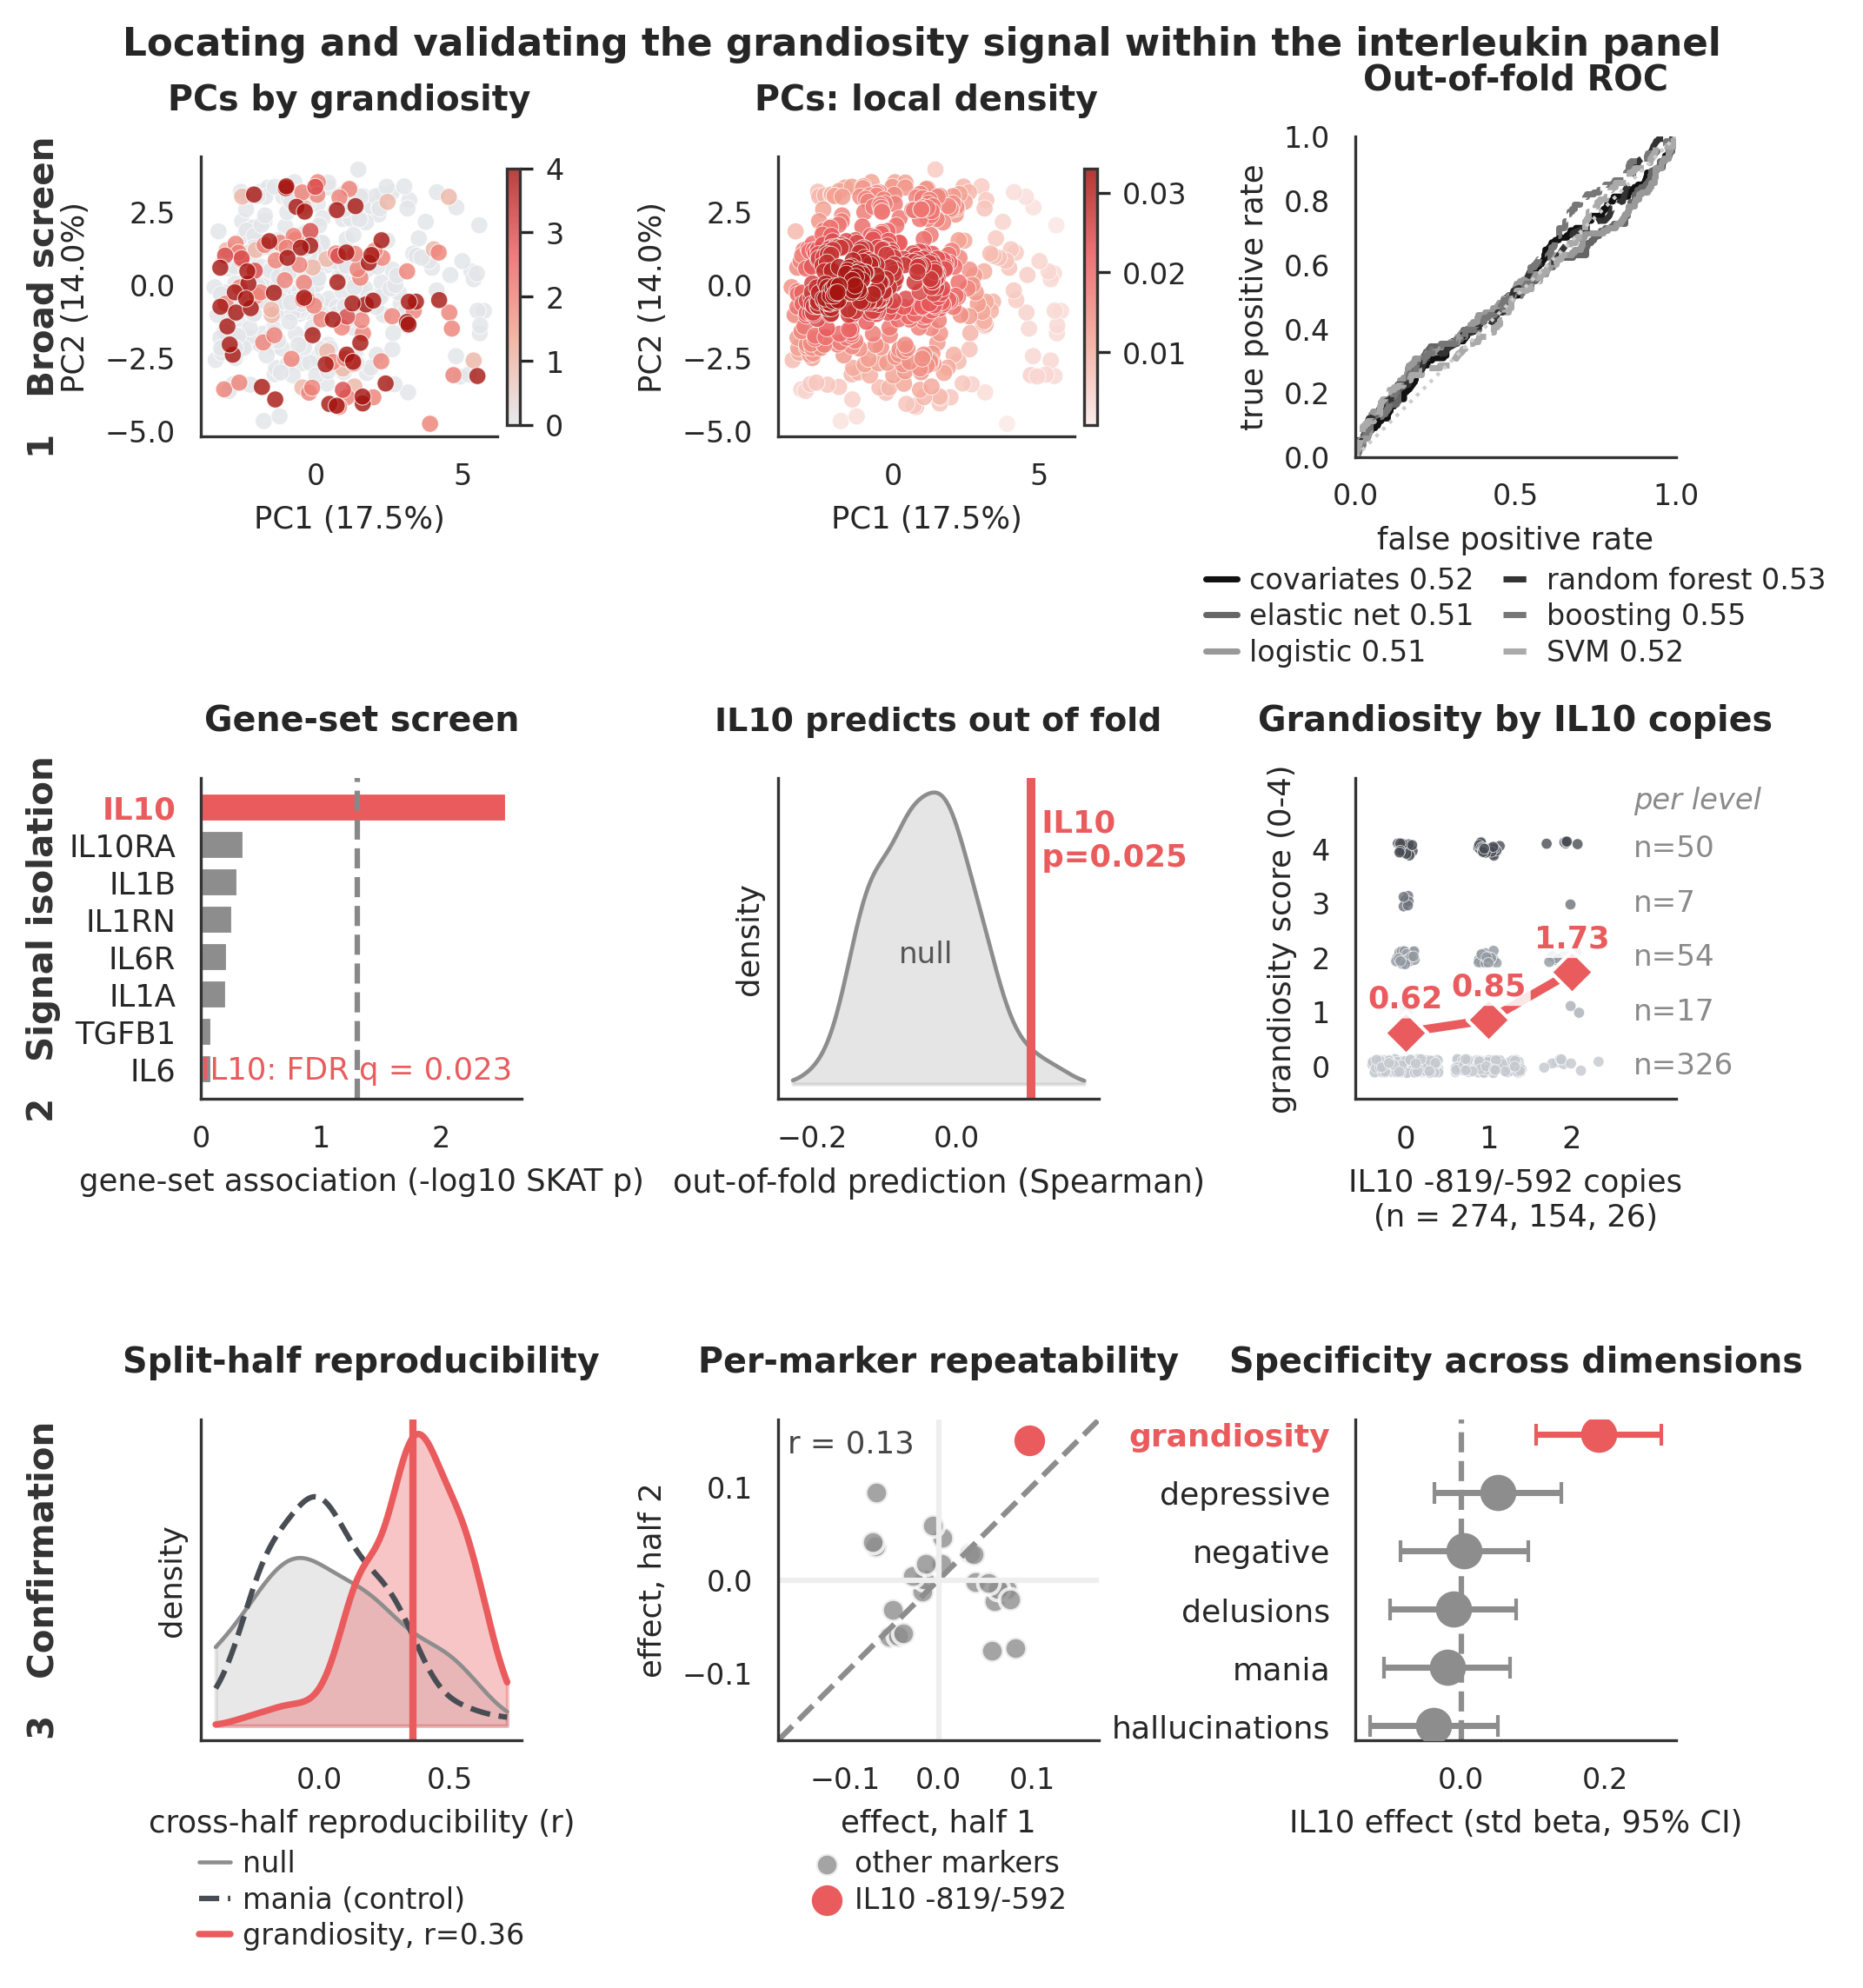

In [11]:
plt.rcParams.update(FIG_RC)
from sklearn.impute import SimpleImputer
REDS = LinearSegmentedColormap.from_list("rd", ["#fbe9e7","#f3a494","#EA5B5D","#a5140f"])
Nv = int(valid.sum()); gv = grand[valid]; ygv = rint(gv); order = np.argsort(gv)

# IL10 out-of-fold prediction (leak-free) with permutation null
def _oof_spear(cols, y, seed=0):
    Xraw = np.column_stack([dosk[cols].values[valid], covdf.values[valid]]); oof = np.zeros(len(y))
    for tr, te in KFold(5, shuffle=True, random_state=seed).split(Xraw):
        imp = SimpleImputer(strategy="mean").fit(Xraw[tr]); Xtr = imp.transform(Xraw[tr]); Xte = imp.transform(Xraw[te])
        scl = StandardScaler().fit(Xtr); mdl = RidgeCV(alphas=np.logspace(-2,3,10)).fit(scl.transform(Xtr), y[tr]); oof[te] = mdl.predict(scl.transform(Xte))
    return stats.spearmanr(oof, y).correlation
_rngA = np.random.default_rng(MASTER_SEED+7)
amp = {"il10": {"obs": _oof_spear(IL10, ygv),
                "null": np.array([_oof_spear(IL10, rint(gv[_rngA.permutation(Nv)])) for _ in range(N_PERM_AMP)])}}

# split-half reproducibility (grandiosity vs mania) with null, and per-marker run-to-run betas
Zm = ((dosk[markers] - dosk[markers].mean())/dosk[markers].std()).values[valid]
Zc0 = ((covdf - covdf.mean())/covdf.std()).values[valid]
def _mbetas(idx, y): return np.array([sm.OLS(y[idx], sm.add_constant(np.column_stack([Zm[idx, j], Zc0[idx]]))).fit().params[1] for j in range(len(markers))])
def _crosshalf(y, seed):
    pr = np.random.default_rng(seed).permutation(Nv); h1, h2 = pr[:Nv//2], pr[Nv//2:]
    return np.corrcoef(_mbetas(h1, y), _mbetas(h2, y))[0,1]
reproduce = {}
for nm, y in [("grandiosity", rint(gv)), ("mania", rint(DIMS["mania"][valid]))]:
    reproduce[nm] = {"obs": np.array([_crosshalf(y, s) for s in range(N_SPLIT)]),
                     "null": np.array([_crosshalf(rint(gv[np.random.default_rng(1000+s).permutation(Nv)]), 9000+s) for s in range(N_SPLIT)])}
_pr = np.random.default_rng(7).permutation(Nv); _h1, _h2 = _pr[:Nv//2], _pr[Nv//2:]
runrun_b1, runrun_b2 = _mbetas(_h1, rint(gv)), _mbetas(_h2, rint(gv)); runrun_il = [markers.index(m) for m in ("rs1800871","rs1800872")]

# dose-response groups
cpv = copies[valid]; _mk = ~np.isnan(cpv); cp = cpv[_mk].astype(int); gr = gv[_mk]; ns = [int((cp==c).sum()) for c in [0,1,2]]

def dose_dots(ax):
    rng = np.random.default_rng(6)
    for c in [0,1,2]:
        idxc = np.where(cp==c)[0]; maxk = max([(gr[idxc]==L).sum() for L in range(5)]) or 1
        for L in range(5):
            sel = idxc[gr[idxc]==L]; k = len(sel)
            if k == 0: continue
            w = 0.40*(k/maxk)**0.62
            ax.scatter(c+rng.uniform(-w,w,k), L+rng.uniform(-0.13,0.13,k), c=[L]*k, cmap=GREYCM, vmin=0, vmax=4, s=9, alpha=.8, edgecolor="white", linewidth=.2, zorder=2)
    means = [gr[cp==c].mean() for c in [0,1,2]]
    ax.plot([0,1,2], means, "-", color=CORAL, lw=2.4, zorder=5); ax.scatter([0,1,2], means, marker="D", s=70, color=CORAL, edgecolor="white", zorder=6)
    for c in [0,1,2]:
        ax.text(c, means[c]+0.34, f"{means[c]:.2f}", ha="center", va="bottom", fontsize=8.4, color=CORAL, fontweight="bold", zorder=8, bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=.85))
    ax.set_xticks([0,1,2]); ax.set_xticklabels(["0", "1", "2"], fontsize=8.5)
    for L in range(5): ax.text(2.74, L, f"n={int((gr==L).sum())}", ha="left", va="center", fontsize=8.2, color="#8a8a8a")
    ax.text(2.74, 5.15, "per level", ha="left", va="top", fontsize=8.1, color="#8a8a8a", style="italic")
    ax.set_xlim(-0.6,3.25); ax.set_ylim(-0.6,5.3); ax.set_yticks([0,1,2,3,4]); ax.set_xlabel(f"IL10 -819/-592 copies\n(n = {ns[0]}, {ns[1]}, {ns[2]})"); ax.set_ylabel("grandiosity score (0-4)")

def envelope(ax, null, obs, xlabel, title):
    xs = np.linspace(min(null.min(),obs)-abs(obs)*0.12-0.02, max(null.max(),obs)*1.1+0.02, 300); k = gaussian_kde(null)
    ax.fill_between(xs, k(xs), color=GREY, alpha=.22); ax.plot(xs, k(xs), color=GREY, lw=1.1); ax.axvline(obs, color=CORAL, lw=2.4)
    ax.text(obs, ax.get_ylim()[1]*0.9, f" IL10\n p={(null>=obs).mean():.3f}", color=CORAL, fontsize=8.5, fontweight="bold", va="top")
    ax.text(np.median(null), k(np.median(null))[0]*0.42, "null", ha="center", fontsize=8.2, color="#555")
    ax.set_xlabel(xlabel, fontsize=8.8); ax.set_ylabel("density"); ax.set_title(title, fontsize=9.1); ax.set_yticks([])

fig = plt.figure(figsize=(6.50, 7.07))
gs = gridspec.GridSpec(3,3, hspace=1.00, wspace=0.80, left=0.115, right=0.985, top=0.925, bottom=0.055)
AX = [[fig.add_subplot(gs[i,j]) for j in range(3)] for i in range(3)]
# row 1: broad screen
a = AX[0][0]; sc = a.scatter(XY[order,0], XY[order,1], c=gv[order], cmap=CORALS, s=22, alpha=.8, edgecolor="white", linewidth=.25)
a.set_xlabel(f"PC1 ({ev[0]:.1f}%)"); a.set_ylabel(f"PC2 ({ev[1]:.1f}%)"); a.set_title("PCs by grandiosity")
a.set_aspect("equal", adjustable="box"); plt.colorbar(sc, ax=a, fraction=.046, pad=0.03, shrink=0.80)
a = AX[0][1]; xy = np.vstack([XY[:,0], XY[:,1]]); dens = gaussian_kde(xy)(xy); oo = np.argsort(dens)
sc2 = a.scatter(XY[oo,0], XY[oo,1], c=dens[oo], cmap=REDS, s=22, alpha=.85, edgecolor="white", linewidth=.2)
a.set_xlabel(f"PC1 ({ev[0]:.1f}%)"); a.set_ylabel(f"PC2 ({ev[1]:.1f}%)"); a.set_title("PCs: local density")
a.set_aspect("equal", adjustable="box"); plt.colorbar(sc2, ax=a, fraction=.046, pad=0.03, shrink=0.80)
a = AX[0][2]
rc = [("covariates","#111","-","covariates %.2f"), ("panel, elastic net","#666","-","elastic net %.2f"),
      ("panel+cov, logistic","#999","-","logistic %.2f"), ("panel+cov, random forest","#333","--","random forest %.2f"),
      ("panel+cov, boosting","#777","--","boosting %.2f"), ("panel+cov, SVM","#aaa","--","SVM %.2f")]
for nm, col, ls, lab in rc:
    d = roc[nm]; a.plot(d["fpr"], d["tpr"], color=col, ls=ls, lw=1.7, label=lab % d["auc"])
a.plot([0,1],[0,1], ls=":", color="#ccc", lw=1); a.set_xlim(0,1); a.set_ylim(0,1)
a.set_xlabel("false positive rate"); a.set_ylabel("true positive rate"); a.set_title("Out-of-fold ROC")
a.set_box_aspect(1); a.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), ncol=2, fontsize=8.0, frameon=False, handlelength=1.1, handletextpad=0.4, labelspacing=0.25, columnspacing=1.0)
# row 2: signal isolation
a = AX[1][0]; sk = pd.Series(skat_p).sort_values(ascending=False); barcols = [CORAL if k=="IL10" else GREY for k in sk.index]
a.barh(range(len(sk)), -np.log10(sk.values), color=barcols); a.axvline(-np.log10(0.05), ls="--", color="#888")
a.set_yticks(range(len(sk))); a.set_yticklabels(sk.index, fontsize=8.5)
for t in a.get_yticklabels():
    if t.get_text()=="IL10": t.set_color(CORAL); t.set_fontweight("bold")
a.set_xlabel("gene-set association (-log10 SKAT p)"); a.set_title("Gene-set screen")
a.text(0.97,0.06,f"IL10: FDR q = {fdr['IL10']:.3f}", transform=a.transAxes, ha="right", fontsize=8.5, color=CORAL)
envelope(AX[1][1], amp["il10"]["null"], amp["il10"]["obs"], "out-of-fold prediction (Spearman)", "IL10 predicts out of fold")
a = AX[1][2]; dose_dots(a); a.set_title("Grandiosity by IL10 copies")
# row 3: confirmation
a = AX[2][0]; rp, rm = reproduce["grandiosity"], reproduce["mania"]; xs = np.linspace(-0.4,0.72,300)
a.fill_between(xs, gaussian_kde(rp["null"])(xs), color=GREY, alpha=.20); a.plot(xs, gaussian_kde(rp["null"])(xs), color=GREY, lw=1.1, label="null")
a.plot(xs, gaussian_kde(rm["obs"])(xs), color=DGREY, lw=1.5, ls="--", label="mania (control)")
a.fill_between(xs, gaussian_kde(rp["obs"])(xs), color=CORAL, alpha=.35); a.plot(xs, gaussian_kde(rp["obs"])(xs), color=CORAL, lw=1.8, label=f"grandiosity, r={rp['obs'].mean():.2f}"); a.axvline(rp["obs"].mean(), color=CORAL, lw=2.0)
a.set_xlabel("cross-half reproducibility (r)"); a.set_ylabel("density"); a.set_title("Split-half reproducibility"); a.set_yticks([])
a.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), ncol=1, frameon=False, fontsize=8.0, handlelength=1.1, handletextpad=0.4, labelspacing=0.25)
a = AX[2][1]; b1, b2, il = runrun_b1, runrun_b2, runrun_il; m2 = np.ones(len(b1), bool); m2[il] = False
a.scatter(b1[m2], b2[m2], c=GREY, s=38, alpha=.8, edgecolor="white", label="other markers"); a.scatter(b1[il], b2[il], c=CORAL, s=90, edgecolor="white", zorder=5, label="IL10 -819/-592")
lim = max(abs(np.r_[b1,b2]))*1.15; a.plot([-lim,lim],[-lim,lim], ls="--", color=GREY); a.axhline(0, color="#eee"); a.axvline(0, color="#eee")
a.set_xlim(-lim,lim); a.set_ylim(-lim,lim); a.set_box_aspect(1); a.set_xlabel("effect, half 1"); a.set_ylabel("effect, half 2"); a.set_title("Per-marker repeatability")
a.text(0.03,0.97, f"r = {np.corrcoef(b1,b2)[0,1]:.2f}", transform=a.transAxes, va="top", fontsize=8.5, color="#444"); a.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), ncol=1, frameon=False, fontsize=8.0, handlelength=1.1, handletextpad=0.4, labelspacing=0.25)
a = AX[2][2]
for i,(nm,bb_,se,_p) in enumerate(forest):
    col = CORAL if nm=="grandiosity" else GREY
    a.errorbar(bb_, i, xerr=1.96*se, fmt="o", color=col, ecolor=col, capsize=3, ms=9, lw=1.7, zorder=3)
a.axvline(0, ls="--", color=GREY, zorder=1); a.set_yticks(range(len(forest))); a.set_yticklabels([t[0] for t in forest], fontsize=8.7)
for t in a.get_yticklabels():
    if t.get_text()=="grandiosity": t.set_color(CORAL); t.set_fontweight("bold")
a.set_xlabel("IL10 effect (std beta, 95% CI)"); a.set_title("Specificity across dimensions")
for r_ in AX:
    for a in r_: sns.despine(ax=a)
for i, lab in enumerate(["1   Broad screen","2   Signal isolation","3   Confirmation"]):
    bpos = gs[i,0].get_position(fig); yc = bpos.y0 + bpos.height/2
    fig.text(0.022, yc, lab, rotation=90, va="center", ha="center", fontsize=9.7, fontweight="bold", color="#333")
fig.suptitle("Locating and validating the grandiosity signal within the interleukin panel", fontsize=10.5, fontweight="bold", x=0.54, y=0.985)
save_tiff(fig, "Figure1_narrative.tif"); plt.show()



## 11. Figure 2: per-patient cross-fitted contribution (internal, descriptive)

Each cell is the cross-fitted contribution of one marker to one patient's grandiosity: a standardised genotype times an out-of-fold effect, with every fold's scaling and effect learned only on the training patients so no patient colours their own row. This is an internal descriptive display for a single cohort, not independent validation.

Markers surviving FDR across the 26: [('rs1800871', '-819', 'A', np.float64(0.0013)), ('rs1800872', '-592', 'T', np.float64(0.0013))]


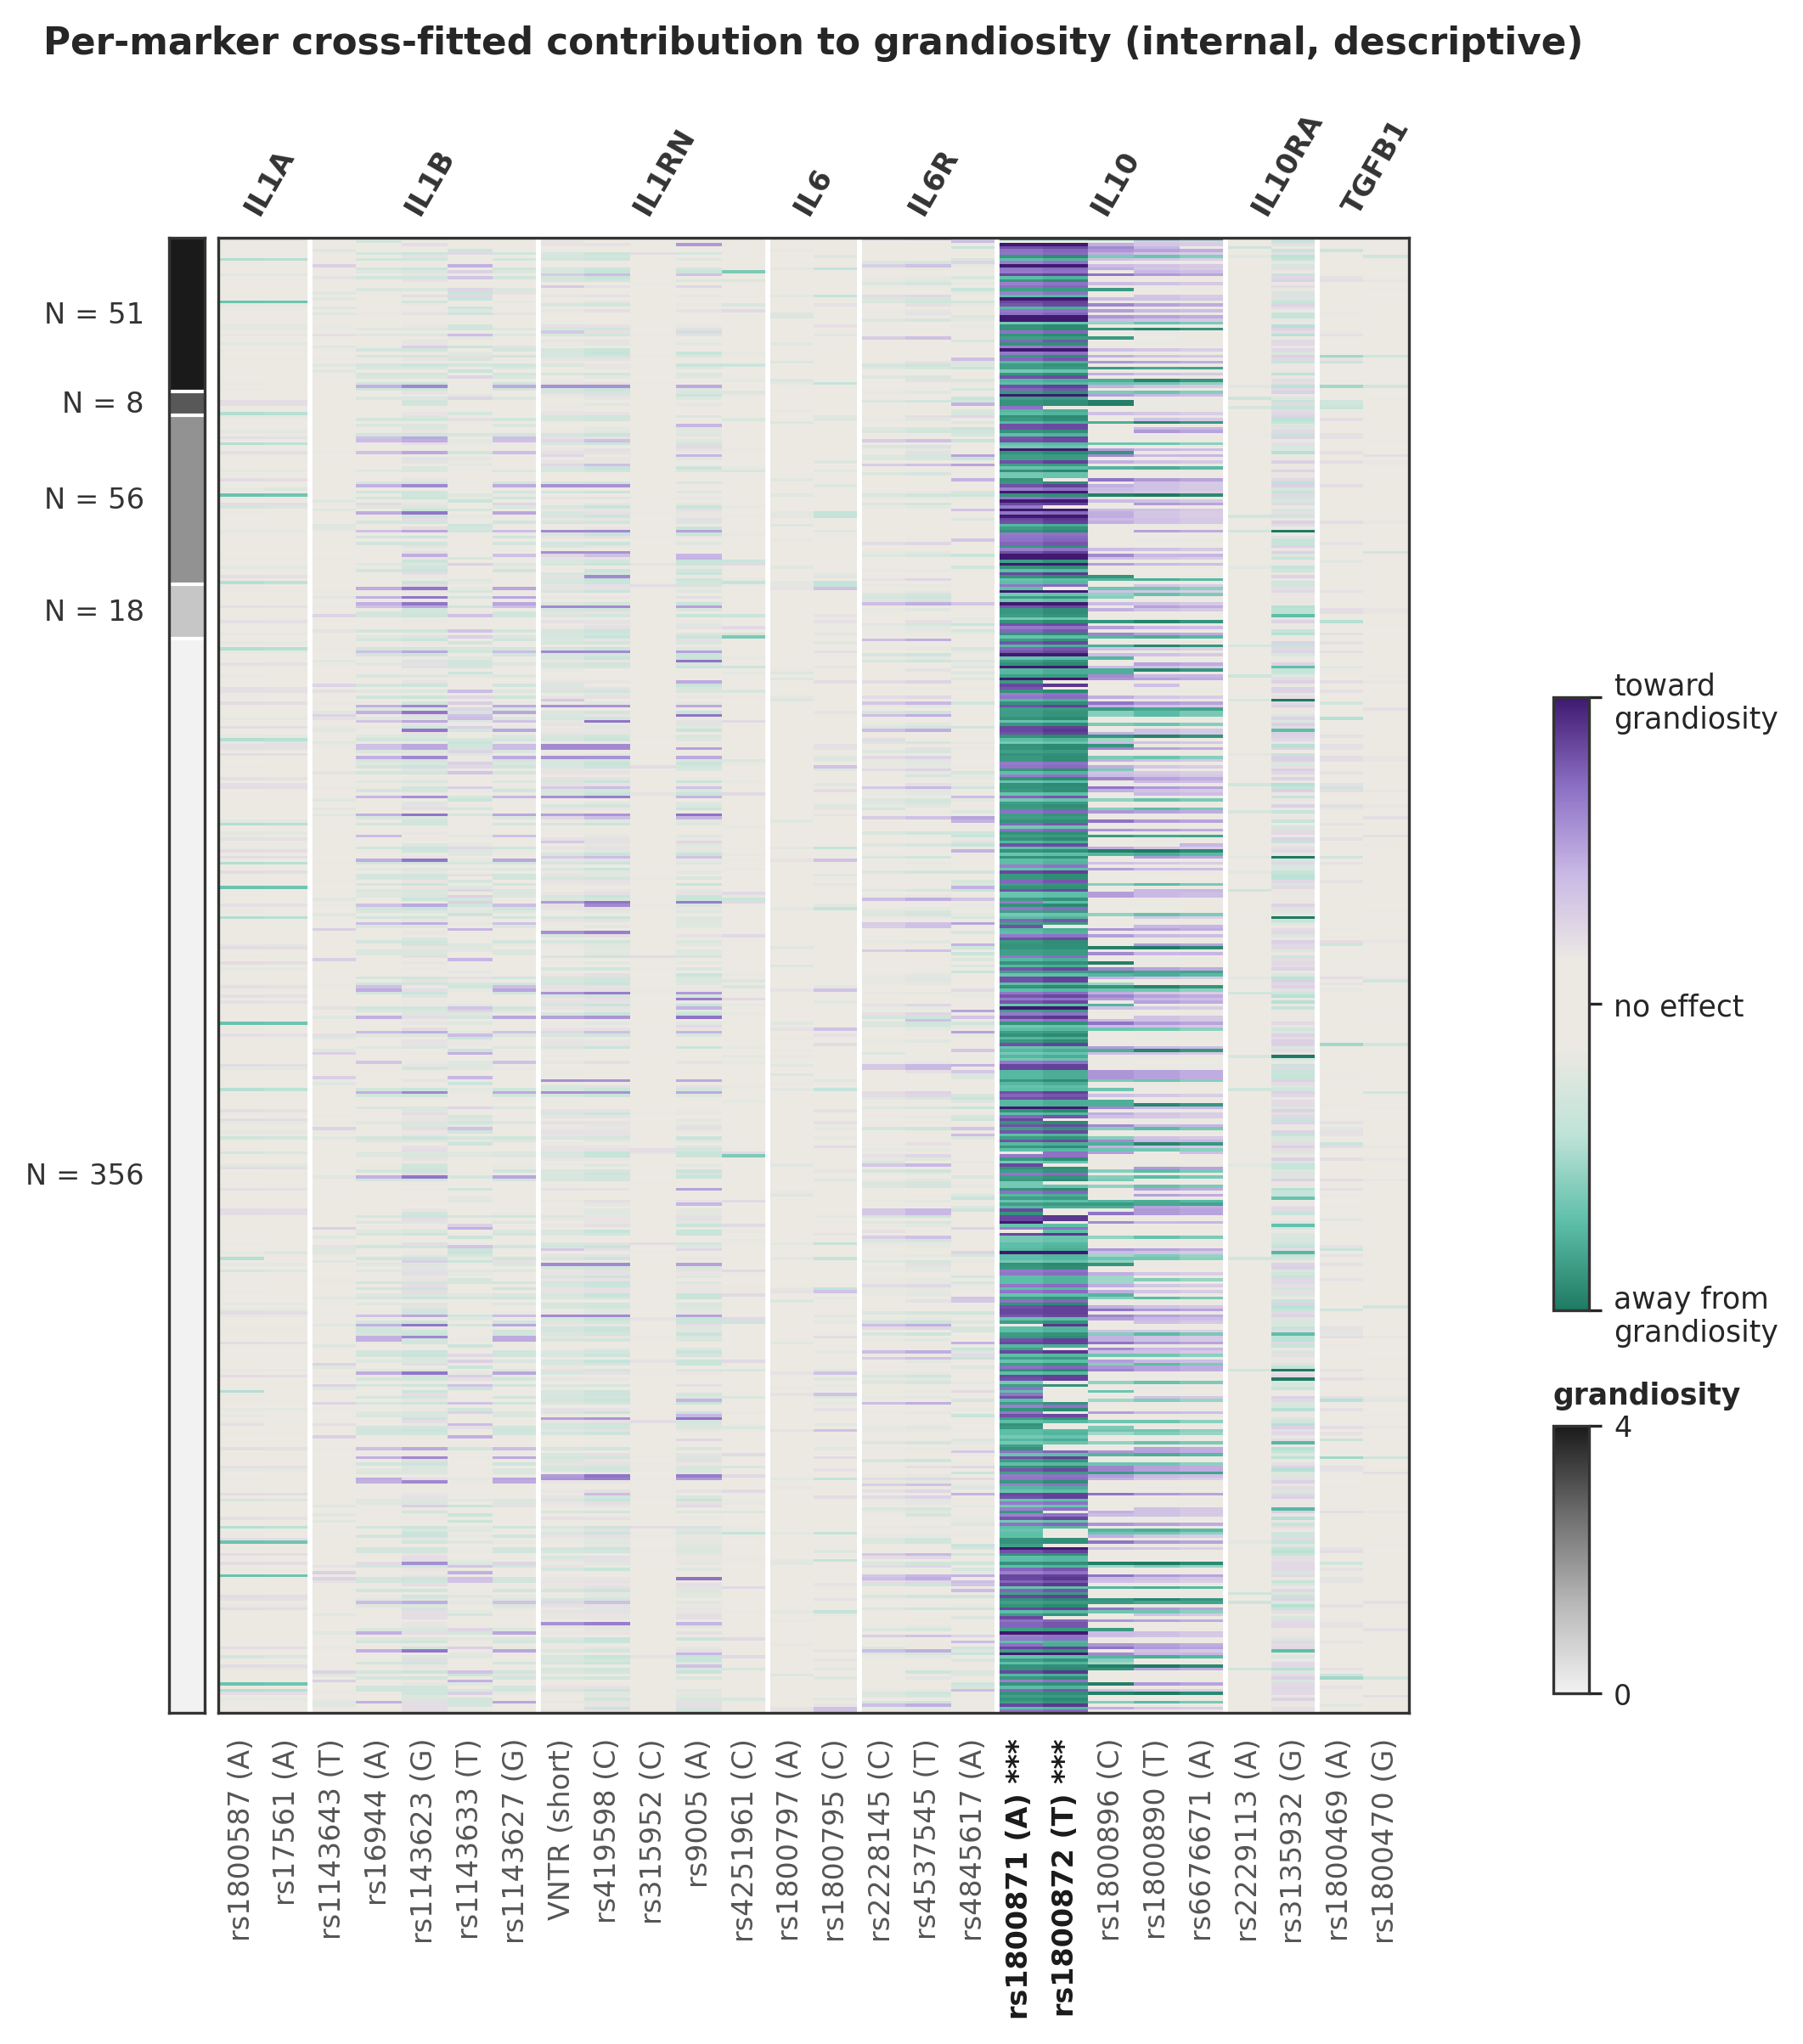

In [12]:
# Patient grandiosity score uses a neutral single-hue ramp, so that it shares no hue
# with either pole of the diverging contribution map, including under simulated
# protanopia, deuteranopia and tritanopia.
GREYCM = LinearSegmentedColormap.from_list("g", ["#f2f2f2","#b8b8b8","#6e6e6e","#1a1a1a"])
plt.rcParams.update(FIG_RC)
from collections import Counter as _Counter

# per-marker cross-fitted contribution (leak-free: scaling and effect learned only on training folds)
contrib = np.zeros((N, len(markers))); gv = rint(grand[valid])
for tr, te in KFold(10, shuffle=True, random_state=7).split(np.arange(N)):
    sc = StandardScaler().fit(dosk[markers].values[valid][tr])
    Ztr = sc.transform(dosk[markers].values[valid][tr]); Zte = sc.transform(dosk[markers].values[valid][te])
    scc = StandardScaler().fit(covdf.values[valid][tr]); Ctr = scc.transform(covdf.values[valid][tr])
    for j in range(len(markers)):
        b = sm.OLS(gv[tr], sm.add_constant(np.column_stack([Ztr[:, j], Ctr]))).fit().params[1]
        contrib[te, j] = Zte[:, j] * b
order = np.argsort(-grand[valid]); Csort = contrib[order]; gsort = grand[valid][order]

# which markers are actually hit: marginal adjusted association with BH-FDR across all 26 markers
snp_col_of = {c.split("_")[0]: c for c in snp_cols}
def counted_allele(m):
    if m not in snp_col_of: return "short"
    v = merged[snp_col_of[m]].dropna().astype(str); v = v[v.str.len() == 2]
    cnt = _Counter("".join(v.tolist())); al = sorted(cnt.keys())
    return (min(al, key=lambda a: cnt[a]) if len(al) > 1 else "?")
gv2 = rint(grand[valid]); Zc2 = ((covdf - covdf.mean())/covdf.std()).values[valid]
mbeta, mp = {}, []
for m in markers:
    d = dos_raw[m].values[valid]; mk = ~np.isnan(d); dd = (d[mk]-np.nanmean(d[mk]))/np.nanstd(d[mk])
    res = sm.OLS(gv2[mk], sm.add_constant(np.column_stack([dd, Zc2[mk]]))).fit()
    mbeta[m] = res.params[1]; mp.append(res.pvalues[1])
mq = dict(zip(markers, bh_fdr(mp))); mpd = dict(zip(markers, mp))
sig_markers = [m for m in markers if mq[m] < 0.05]
POS = {"rs1800896":"-1082","rs1800871":"-819","rs1800872":"-592","rs16944":"-511","rs1800795":"-174","rs1800469":"-509"}
print("Markers surviving FDR across the 26:", [(m, POS.get(m,''), counted_allele(m), round(mq[m],4)) for m in sig_markers])

vlo, vhi = 0.12, 0.15
fig = plt.figure(figsize=(7.01, 7.52))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.03, 1, 0.11], wspace=0.03)
ax_sd = fig.add_subplot(gs[0]); ax_m = fig.add_subplot(gs[1]); fig.add_subplot(gs[2]).axis("off")

# left strip: grandiosity, sorted high at top, with white level separators and N per level
ax_sd.imshow(gsort[:,None], aspect="auto", cmap=GREYCM); ax_sd.set_xticks([]); ax_sd.set_yticks([])
lv = [4,3,2,1,0]; ct = [int((gsort==L).sum()) for L in lv]; bnd = np.cumsum([0]+ct)
for b in bnd[1:-1]: ax_sd.axhline(b-0.5, color="white", lw=1.0)
for i, L in enumerate(lv):
    if ct[i] > 0: ax_sd.text(-1.2, (bnd[i]+bnd[i+1])/2 - 0.5, f"N = {ct[i]}", ha="right", va="center", fontsize=8.1, color="#333", clip_on=False)
ax_sd.set_xlim(-0.5, 0.5)

ax_m.imshow(Csort, aspect="auto", cmap=TGP, norm=TwoSlopeNorm(vmin=-vlo, vcenter=0, vmax=vhi), interpolation="nearest"); ax_m.set_yticks([])
def _star(m):
    if mq[m] < 0.05: return " ***"
    if mpd[m] < 0.05: return " *"
    return ""
labs = [f"{m} ({counted_allele(m)}){_star(m)}" for m in markers]
ax_m.set_xticks(range(len(markers))); tl = ax_m.set_xticklabels(labs, rotation=90, fontsize=8.0)
for t, m in zip(tl, markers):
    if mq[m] < 0.05: t.set_color("#1a1a1a"); t.set_fontweight("bold")
    else: t.set_color("#555")
nrow = len(gsort); px = 0
for gn in GENE_ORDER:
    w = len([m for m in GENES[gn] if m in markers]); ax_m.text(px+w/2-0.5, -0.014*nrow, gn, ha="left", va="bottom", rotation=60, rotation_mode="anchor", fontsize=8.1, fontweight="bold", color="#333")
    px += w
    if px < len(markers): ax_m.axvline(px-0.5, color="white", lw=1.4)
ax_m.set_title("Per-marker cross-fitted contribution to grandiosity (internal, descriptive)", pad=52, fontsize=10.5)
cax = fig.add_axes([0.90, 0.32, 0.02, 0.32]); sm2 = ScalarMappable(norm=TwoSlopeNorm(vmin=-vlo, vcenter=0, vmax=vhi), cmap=TGP); sm2.set_array([])
cb = fig.colorbar(sm2, cax=cax, ticks=[-vlo, 0, vhi]); cb.ax.set_yticklabels(["away from\ngrandiosity","no effect","toward\ngrandiosity"], fontsize=8.3)
cax2 = fig.add_axes([0.90, 0.12, 0.02, 0.14]); sm3 = ScalarMappable(norm=Normalize(0,4), cmap=GREYCM); sm3.set_array([])
cb2 = fig.colorbar(sm3, cax=cax2, ticks=[0,4]); cb2.set_ticklabels(["0","4"]); cax2.set_title("grandiosity", fontsize=8.3, loc="left", pad=6)
save_tiff(fig, "Figure2_contribution.tif"); plt.show()



## 12. Limitations

- All analyses are internal to a single Polish schizophrenia cohort. The held-out split separates selection from evaluation within this cohort but does not replace independent replication, which this result still needs.
- The finding is a recessive-pattern effect concentrated in the roughly five percent of patients carrying two copies of the -819/-592 haplotype. It rests on a small number of homozygotes, so the interval is wide and the estimate is fragile despite being reproducible in direction.
- The two tag SNPs are in near-complete linkage disequilibrium and are treated as one locus. The canonical -1082 promoter SNP is null here, so the effect is labelled by position and is not asserted to be the functional low-producer haplotype.
- Sex (OPCRIT item 3) is coded 0 for male and 1 for female, as given in the cohort data dictionary.
- Permutation and split budgets are set for a working run. Raise N_PERM_SEL, N_SPLIT_HONEST, N_PERM_AMP, and N_SPLIT for a final run to tighten the tail estimates.

**References (DOIs verified online):** SKAT, Wu et al. 2011, doi:10.1016/j.ajhg.2011.05.029; Liu chi-square approximation, Liu et al. 2009, doi:10.1016/j.csda.2008.11.025; Firth penalization, Firth 1993, doi:10.1093/biomet/80.1.27, and Heinze and Schemper 2002, doi:10.1002/sim.1047; OPCRIT, McGuffin et al. 1991, doi:10.1001/archpsyc.1991.01810320088015; IL-10 and schizophrenia, Gao et al. 2014, doi:10.1371/journal.pone.0090407.


## 13. Environment and reproducibility

In [13]:
import sys, numpy, pandas, scipy, sklearn, statsmodels, matplotlib, seaborn, openpyxl
print("Python", sys.version.split()[0])
for _m in [numpy, pandas, scipy, sklearn, statsmodels, matplotlib, seaborn, openpyxl]:
    print(f"{_m.__name__:12s} {_m.__version__}")
print("\nA fixed master seed (MASTER_SEED) plus per-step seeds make every result deterministic:")
print("a fresh top-to-bottom run reproduces all printed outputs and both figures exactly under these package versions.")
print("The SKAT, selection-adjusted permutation, Firth, and held-out-split results are robust to version differences;")
print("the supervised AUCs and out-of-fold correlations may move by a few thousandths on other scikit-learn builds.")

Python 3.12.3
numpy        2.4.4
pandas       3.0.2
scipy        1.17.1
sklearn      1.8.0
statsmodels  0.15.0
matplotlib   3.10.8
seaborn      0.13.2
openpyxl     3.1.5

A fixed master seed (MASTER_SEED) plus per-step seeds make every result deterministic:
a fresh top-to-bottom run reproduces all printed outputs and both figures exactly under these package versions.
The SKAT, selection-adjusted permutation, Firth, and held-out-split results are robust to version differences;
the supervised AUCs and out-of-fold correlations may move by a few thousandths on other scikit-learn builds.


## Verification

The cell above records every headline result and checks it against the value printed in the manuscript. It raises if any of them disagree.


In [14]:
# ---- headline results: recorded and verified against the published values ----
# Every number quoted in the Results is written here, then checked against the
# value printed in the manuscript. A run that reproduces the analysis passes all
# checks; a run that does not fails loudly rather than quietly disagreeing with
# the paper.
import json

headline = {
    "N_linked":                 N_LINK,
    "N_analysis":               N,
    "n_markers":                len(markers),
    "n_genes":                  len(GENES),
    "n_any_grandiosity":        int(np.nansum(grand[valid] > 0)),
    "n_dosage_cells":           n_dosage_cells,
    "n_imputed_dosage_cells":   n_imputed,
    "pct_imputed_dosage_cells": round(pct_imputed, 2),
    "IL10_SKAT_p":              float(skat_p["IL10"]),
    "IL10_FDR_q":               float(fdr["IL10"]),
    "IL10_p_all_snps":          float(p_all),
    "IL10_p_drop_tags":         float(p_drop),
    "IL10_p_tags_only":         float(p_tags),
    "firth_OR_adjusted":        float(OR_f),
    "firth_CI_low":             float(ci_f[0]),
    "firth_CI_high":            float(ci_f[1]),
    "firth_p_adjusted":         float(p_f),
    "firth_OR_unadjusted":      float(OR_fu),
    "OR_one_copy":              OR_c1,
    "OR_one_copy_CI_low":       ci_c1[0],
    "OR_one_copy_CI_high":      ci_c1[1],
    "OR_two_copy":              OR_c2,
    "OR_two_copy_CI_low":       ci_c2[0],
    "OR_two_copy_CI_high":      ci_c2[1],
    "spec_beta_grandiosity":    float([b for nm,b,se,p in forest if nm=="grandiosity"][0]),
    "spec_beta_grandiosity_CI_low":  float([b-1.96*se for nm,b,se,p in forest if nm=="grandiosity"][0]),
    "spec_beta_grandiosity_CI_high": float([b+1.96*se for nm,b,se,p in forest if nm=="grandiosity"][0]),
    "jackknife_OR_min":         float(min(ors)),
    "jackknife_OR_max":         float(max(ors)),
}
with open("main_manifest.json", "w") as fh:
    json.dump(headline, fh, indent=1, sort_keys=True)

published = {
    "N_linked": (490, 0), "N_analysis": (489, 0), "n_markers": (26, 0),
    "n_genes": (8, 0), "n_any_grandiosity": (133, 0),
    "n_dosage_cells": (12714, 0), "n_imputed_dosage_cells": (169, 0),
    "pct_imputed_dosage_cells": (1.33, 0.005),
    "IL10_SKAT_p": (0.0028, 5e-5), "IL10_FDR_q": (0.023, 5e-4),
    "IL10_p_all_snps": (0.0028, 5e-5), "IL10_p_drop_tags": (0.0824, 5e-4),
    "IL10_p_tags_only": (0.0002, 5e-5),
    "firth_OR_adjusted": (5.28, 0.005), "firth_CI_low": (2.37, 0.005),
    "firth_CI_high": (12.48, 0.005), "firth_p_adjusted": (4.5e-5, 5e-7),
    "firth_OR_unadjusted": (5.25, 0.005),
    "OR_one_copy": (1.37, 0.005), "OR_two_copy": (6.07, 0.005),
    "spec_beta_grandiosity": (0.19, 0.005),
    "jackknife_OR_min": (4.93, 0.005), "jackknife_OR_max": (5.96, 0.005),
}
failed = [(k, headline[k], v) for k, (v, tol) in published.items()
          if abs(headline[k] - v) > tol]
if failed:
    for k, got, want in failed:
        print(f"  MISMATCH {k}: this run {got!r}, manuscript {want!r}")
    raise AssertionError(f"{len(failed)} headline result(s) do not match the published values")
print(f"All {len(published)} headline results match the published values.")
print("Written: main_manifest.json")


All 23 headline results match the published values.
Written: main_manifest.json
